In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
# Parameters of the damped harmonic oscillator
m = 1.0       # mass
c = 0.4       # damping coefficient
k = 4.0       # spring constant

# Initial conditions
x0 = 1.0      # initial displacement
v0 = 0.0      # initial velocity

# Time span
t_start = 0.0
t_end = 10.0

# Time points for evaluation
t_eval = np.linspace(t_start, t_end, 500)

In [4]:
def damped_oscillator(t, y, m, c, k):
    x, v = y
    dxdt = v
    dvdt = -(c/m) * v - (k/m) * x
    return [dxdt, dvdt]

In [5]:
solution = solve_ivp(
    fun=lambda t, y: damped_oscillator(t, y, m, c, k),
    t_span=(t_start, t_end),
    y0=[x0, v0],
    t_eval=t_eval,
    method='RK45'
)

t = solution.t
x = solution.y[0]
v = solution.y[1]

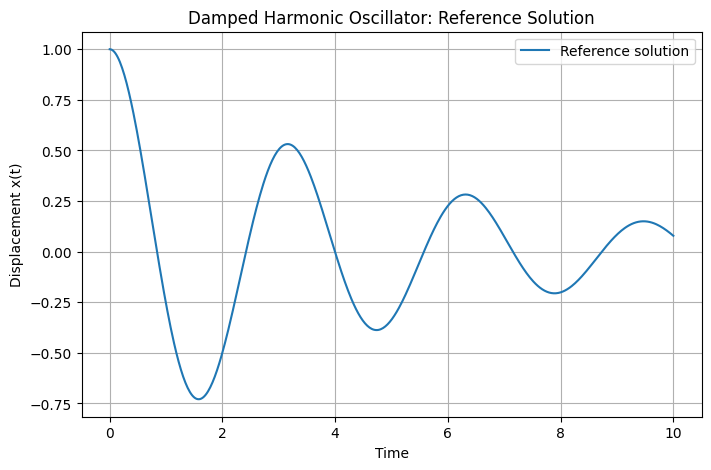

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(t, x, label='Reference solution')
plt.xlabel('Time')
plt.ylabel('Displacement x(t)')
plt.title('Damped Harmonic Oscillator: Reference Solution')
plt.legend()
plt.grid(True)
plt.show()

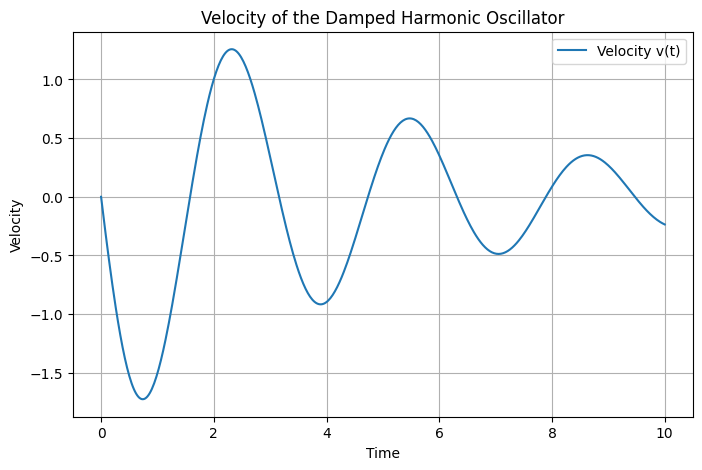

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(t, v, label='Velocity v(t)')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.title('Velocity of the Damped Harmonic Oscillator')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

The solution shows an underdamped oscillatory behavior.  
The displacement oscillates over time, but its amplitude gradually decreases because of damping.  
This reference solution will be used later to compare Euler, RK4, and PINN results.